In [1]:
!pip install geopandas
!pip install rasterio
!pip install geemap
!pip install torch
!pip install torchvision
!pip install scikit-learn
!pip install matplotlib
!pip install pandas
!pip install numpy

In [2]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from shapely.geometry import Point, box
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from PIL import Image

In [3]:
delhi_ncr = gpd.read_file(r"C:\Users\DATTA\srip-delhi\dataset\delhi_ncr_region.geojson")
delhi_airshed = gpd.read_file(r"C:\Users\DATTA\srip-delhi\dataset\delhi_airshed.geojson")

delhi_ncr.head()

,geometry
0,"POLYGON ((76.85108 28.22115, 76.85219 28.22098..."
1,"POLYGON ((77.15903 29.29436, 77.15999 29.29427..."
2,"MULTIPOLYGON (((77.07565 27.27704, 77.07819 27..."
3,"POLYGON ((77.97073 28.71104, 77.97089 28.71096..."
4,"POLYGON ((77.2143 28.78524, 77.21521 28.78514,..."


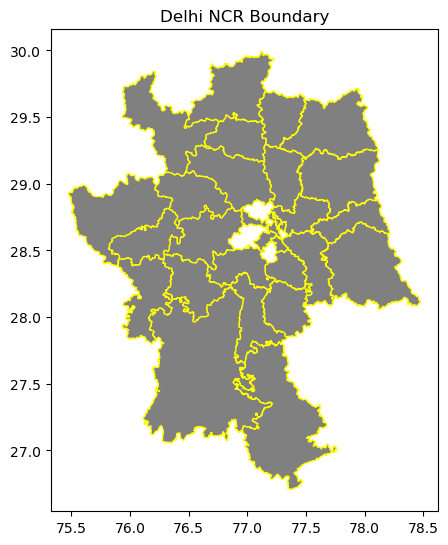

In [24]:
fig, ax = plt.subplots(figsize=(5,10))
delhi_ncr.plot(ax=ax, edgecolor='yellow', facecolor='grey')
plt.title("Delhi NCR Boundary")
plt.show()

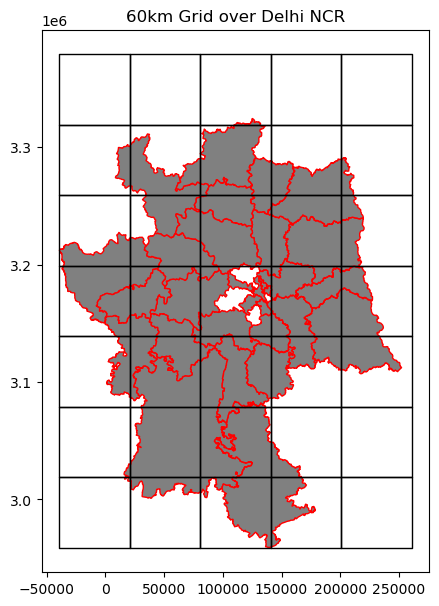

In [25]:
delhi_ncr_utm = delhi_ncr.to_crs(epsg=32644)
minx, miny, maxx, maxy = delhi_ncr_utm.total_bounds
grid_size = 60000
grid_cells = []
for x in np.arange(minx, maxx, grid_size):
    for y in np.arange(miny, maxy, grid_size):
        grid_cells.append(box(x, y, x+grid_size, y+grid_size))
grid = gpd.GeoDataFrame(geometry=grid_cells, crs="EPSG:32644")
fig, ax = plt.subplots(figsize=(5,10))
delhi_ncr_utm.plot(ax=ax, facecolor='grey', edgecolor='red')
grid.plot(ax=ax, facecolor='none', edgecolor='black')
plt.title("60km Grid over Delhi NCR")
plt.show()

In [6]:
import random
image_folder = "dataset/sentinel_images"
image_files = os.listdir(image_folder)
print("Total images:", len(image_files))
image_files = random.sample(image_files, 300)
print("Random images selected:", len(image_files))

Total images: 9216
Random images selected: 300


In [7]:
delhi_airshed = delhi_airshed.to_crs(epsg=4326)
filtered_images = []
for img in image_files:
    lat, lon = img.replace(".png","").split("_")
    lat = float(lat)
    lon = float(lon)
    point = Point(lon, lat)
    if delhi_airshed.contains(point).any():
        filtered_images.append(img)
print("Images inside airshed:", len(filtered_images))

Images inside airshed: 300


In [8]:
landcover = rasterio.open(r"C:\Users\DATTA\srip-delhi\dataset\worldcover_bbox_delhi_ncr_2021.tif")

In [9]:
labels = []
for img in filtered_images:
    lat, lon = img.replace(".png","").split("_")
    lat = float(lat)
    lon = float(lon)
    row, col = landcover.index(lon, lat)
    window = rasterio.windows.Window(col-64, row-64, 128, 128)
    patch = landcover.read(1, window=window)
    values, counts = np.unique(patch, return_counts=True)
    label = values[np.argmax(counts)]
    labels.append(label)

In [10]:
mapping = {
    10:0, 20:0, 30:0,   # vegetation
    40:1,               # cropland
    50:2,               # builtup
    60:3,               # others
    80:4                # water
}
y = [mapping.get(l,3) for l in labels]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    filtered_images,
    y,
    test_size=0.4,
    random_state=42
)

In [12]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])
class SatelliteDataset(torch.utils.data.Dataset):  
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels        
    def __len__(self):
        return len(self.images)    
    def __getitem__(self, idx):
        img = Image.open(os.path.join(image_folder,self.images[idx]))
        img = transform(img)
        label = self.labels[idx]
        return img, label

In [13]:
train_dataset = SatelliteDataset(X_train,y_train)
test_dataset = SatelliteDataset(X_test,y_test)
train_loader = torch.utils.data.DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,batch_size=32)

In [14]:
model = torchvision.models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features,5)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

C:\Users\DATTA\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\DATTA\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
for epoch in range(5):
    model.train()
    for images,labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs,labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print("Epoch",epoch,"Loss:",loss.item())

Epoch 0 Loss: 0.71407550573349
Epoch 1 Loss: 0.009260809049010277
Epoch 2 Loss: 0.07641210407018661
Epoch 3 Loss: 0.03671354800462723
Epoch 4 Loss: 0.04222670942544937


In [16]:
model.eval()
preds = []
true = []
with torch.no_grad():
    for images,labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        predicted = torch.argmax(outputs,1).cpu().numpy()
        preds.extend(predicted)
        true.extend(labels.numpy())

In [17]:
print("Accuracy:", accuracy_score(true,preds))
print("F1 Score:", f1_score(true,preds,average="weighted"))

Accuracy: 0.8
F1 Score: 0.783879142300195


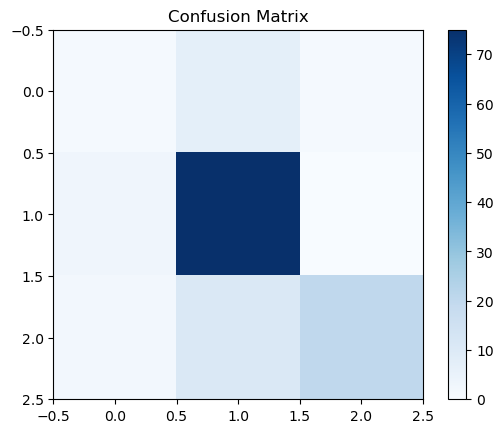

In [23]:
cm = confusion_matrix(true,preds)
plt.imshow(cm,cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()